# Module 2 — Emotion Classifier (DistilBERT)

**Project:** RAG-Based Mental Health Support Chatbot  
**Purpose:** Detect the dominant emotion in a user's message so the chatbot can adjust its tone.

---

The 6 emotion classes and their chatbot relevance:

| Label | Code | Chatbot Response Strategy |
|-------|------|---------------------------|
| sadness | 0 | Compassionate, validating tone |
| joy | 1 | Encouraging, celebratory |
| love | 2 | Warm, affirming |
| anger | 3 | De-escalating, calm |
| fear | 4 | Reassuring, grounding |
| surprise | 5 | Curious, exploratory |

**Model:** DistilBERT — a distilled version of BERT that is 40% smaller, 60% faster, while retaining 97% of BERT's performance on GLUE benchmarks.

| Step | Description |
|------|-------------|
| 1 | Imports & Setup |
| 2 | Dataset Loading |
| 3 | EDA |
| 4 | Preprocessing |
| 5 | Tokenization |
| 6 | Dataset Preparation |
| 7 | Model Setup |
| 8 | Training |
| 9 | Training Curves |
| 10 | Evaluation |
| 11 | Model Saving |
| 12 | Inference Demo |

## 1. Imports & Setup

In [1]:
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# HuggingFace ecosystem
from datasets import load_dataset, DatasetDict
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import evaluate

import torch

# Configuration
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():   DEVICE = 'mps'
elif torch.cuda.is_available():          DEVICE = 'cuda'
else:                                    DEVICE = 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: mps
PyTorch version: 2.10.0


## 2. Dataset Loading

**Dataset:** `dair-ai/emotion` — English Twitter messages labelled with 6 emotions.  
- Train: 16,000 samples  
- Validation: 2,000 samples  
- Test: 2,000 samples  

In [2]:
# Load from HuggingFace Hub
raw_dataset = load_dataset('dair-ai/emotion')
print(raw_dataset)

# Inspect the label mapping
label_names = raw_dataset['train'].features['label'].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print(f'\nLabel mapping: {id2label}')
print(f'Num classes  : {len(label_names)}')

# Convert to pandas for EDA
df_train = raw_dataset['train'].to_pandas()
df_val   = raw_dataset['validation'].to_pandas()
df_test  = raw_dataset['test'].to_pandas()

# Add string label column
for df in [df_train, df_val, df_test]:
    df['emotion'] = df['label'].map(id2label)

df_train.head()

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Label mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Num classes  : 6


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 3. Exploratory Data Analysis (EDA)

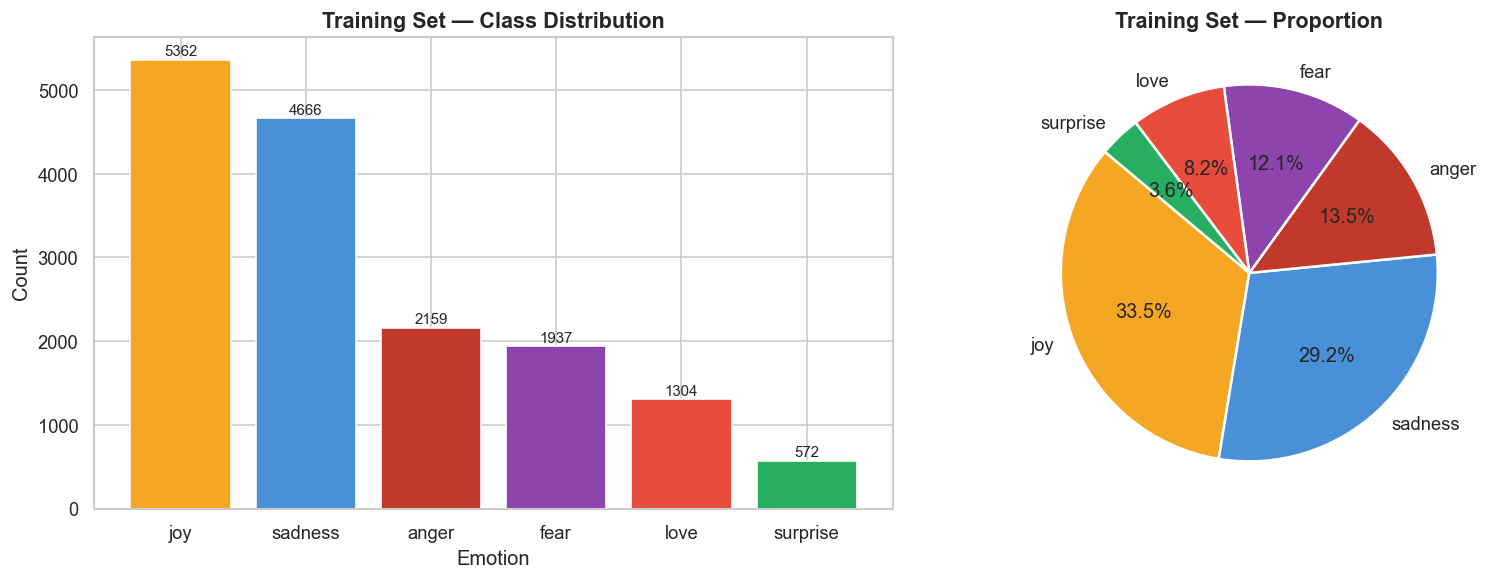

Class imbalance note: sadness/joy are over-represented. This motivates using weighted F1 as the metric.


In [3]:
# --- 3.1  Class distribution ---
EMOTION_COLORS = {
    'sadness' : '#4A90D9',
    'joy'     : '#F5A623',
    'love'    : '#E74C3C',
    'anger'   : '#C0392B',
    'fear'    : '#8E44AD',
    'surprise': '#27AE60'
}

train_counts = df_train['emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — training set
colors = [EMOTION_COLORS[e] for e in train_counts.index]
axes[0].bar(train_counts.index, train_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Training Set — Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(zip(train_counts.index, train_counts.values)):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=9)

# Pie chart
axes[1].pie(
    train_counts.values,
    labels=train_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Training Set — Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Class imbalance note: sadness/joy are over-represented. This motivates using weighted F1 as the metric.')

In [4]:
# --- 3.2  Sample texts per emotion ---
print('Sample texts per emotion (training set):\n')
for emotion in label_names:
    sample = df_train[df_train['emotion'] == emotion]['text'].iloc[0]
    print(f'[{emotion:8s}] {sample}')

Sample texts per emotion (training set):

[sadness ] i didnt feel humiliated
[joy     ] i have been with petronas for years i feel that petronas has performed well and made a huge profit
[love    ] i am ever feeling nostalgic about the fireplace i will know that it is still on the property
[anger   ] im grabbing a minute to post i feel greedy wrong
[fear    ] i feel as confused about life as a teenager or as jaded as a year old man
[surprise] ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny


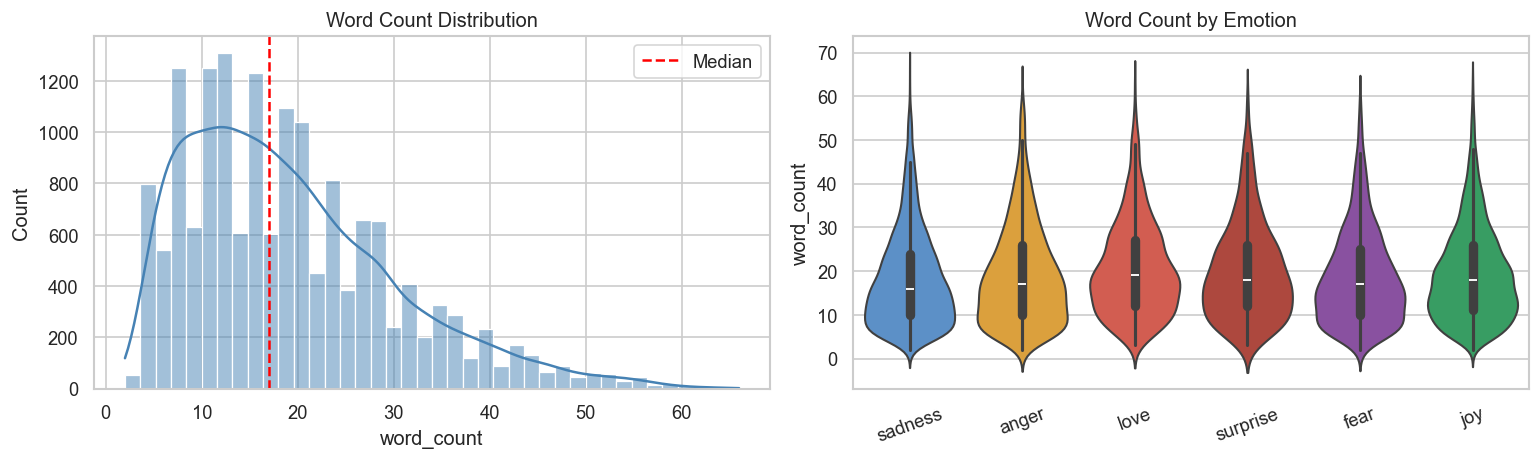

Word count stats:
count    16000.0
mean        19.2
std         11.0
min          2.0
25%         11.0
50%         17.0
75%         25.0
max         66.0
Name: word_count, dtype: float64


In [5]:
# --- 3.3  Token length distribution ---
# Use a fast approximation: word count as proxy for token length
df_train['word_count'] = df_train['text'].str.split().str.len()
df_train['char_count'] = df_train['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_train['word_count'], bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Word Count Distribution', fontsize=12)
axes[0].axvline(df_train['word_count'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

sns.violinplot(
    data=df_train, x='emotion', y='word_count',
    palette=list(EMOTION_COLORS.values()), ax=axes[1]
)
axes[1].set_title('Word Count by Emotion', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(f'Word count stats:\n{df_train["word_count"].describe().round(1)}')

## 4. Preprocessing

We apply light cleaning before tokenisation:
- Remove URLs (not emotion-carrying)
- Remove @mentions (privacy + noise)
- Collapse extra whitespace
- Keep punctuation (exclamation marks, question marks carry emotional signal)

In [6]:
def clean_emotion_text(text: str) -> str:
    """
    Light cleaning for emotion classification.
    Keeps punctuation and capitalisation as they carry emotional signal.
    """
    if not isinstance(text, str):
        return ''
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtag symbol but keep word
    text = re.sub(r'#(\w+)', r'\1', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Apply to all splits
for df in [df_train, df_val, df_test]:
    df['clean_text'] = df['text'].map(clean_emotion_text)

# Spot check
comparison = df_train[['text', 'clean_text', 'emotion']].sample(4, random_state=SEED)
print(comparison.to_string(index=False))

                                                                                text                                                                           clean_text emotion
                                  ive made it through a week i just feel beaten down                                   ive made it through a week i just feel beaten down sadness
                                                  i feel this strategy is worthwhile                                                   i feel this strategy is worthwhile     joy
i feel so worthless and weak what does he have to say that s what i want to find out i feel so worthless and weak what does he have to say that s what i want to find out sadness
                                                                   i feel clever nov                                                                    i feel clever nov     joy


## 5. Tokenization

We use `DistilBertTokenizerFast` for:
- **Subword tokenisation** (WordPiece) — handles OOV words gracefully
- `max_length=128` — covers >99% of samples (median is ~15 words) with padding
- `truncation=True` — safely handles the rare long samples
- `padding='max_length'` — produces fixed-length tensors for batching

In [7]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )

# Quick demonstration
sample_text = 'I feel really anxious and scared about tomorrow.'
tokens = tokenizer(sample_text, return_tensors='pt', max_length=MAX_LENGTH, truncation=True, padding='max_length')
print('Sample tokenisation:')
print(f'  Input IDs shape: {tokens["input_ids"].shape}')
print(f'  Decoded tokens : {tokenizer.convert_ids_to_tokens(tokens["input_ids"][0][:20])}')

Sample tokenisation:
  Input IDs shape: torch.Size([1, 128])
  Decoded tokens : ['[CLS]', 'i', 'feel', 'really', 'anxious', 'and', 'scared', 'about', 'tomorrow', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 6. Dataset Preparation (HuggingFace Dataset Format)

In [8]:
from datasets import Dataset

# Create HuggingFace Dataset objects from pandas DataFrames
train_hf = Dataset.from_pandas(df_train[['clean_text', 'label']].rename(columns={'clean_text': 'text', 'label': 'labels'}))
val_hf   = Dataset.from_pandas(df_val[['clean_text', 'label']].rename(columns={'clean_text': 'text', 'label': 'labels'}))
test_hf  = Dataset.from_pandas(df_test[['clean_text', 'label']].rename(columns={'clean_text': 'text', 'label': 'labels'}))

# Apply tokenization in batch
train_tokenized = train_hf.map(tokenize_function, batched=True, batch_size=512)
val_tokenized   = val_hf.map(tokenize_function, batched=True, batch_size=512)
test_tokenized  = test_hf.map(tokenize_function, batched=True, batch_size=512)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'labels']
train_tokenized.set_format(type='torch', columns=cols)
val_tokenized.set_format(type='torch', columns=cols)
test_tokenized.set_format(type='torch', columns=cols)

print('Tokenized dataset shapes:')
print(f'  Train : {train_tokenized.shape}')
print(f'  Val   : {val_tokenized.shape}')
print(f'  Test  : {test_tokenized.shape}')
print(f'  Features: {train_tokenized.features}')

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:  38%|███▊      | 6144/16000 [00:00<00:00, 31073.00 examples/s]

Map:  83%|████████▎ | 13312/16000 [00:00<00:00, 45678.83 examples/s]

Map: 100%|██████████| 16000/16000 [00:00<00:00, 45064.46 examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map: 100%|██████████| 2000/2000 [00:00<00:00, 51366.48 examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map: 100%|██████████| 2000/2000 [00:00<00:00, 51795.28 examples/s]

Tokenized dataset shapes:
  Train : (16000, 4)
  Val   : (2000, 4)
  Test  : (2000, 4)
  Features: {'text': Value('string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


## 7. Model Setup

`DistilBertForSequenceClassification` appends a classification head (linear layer) on top of the DistilBERT encoder.  
We fine-tune **all layers** end-to-end — the pre-trained weights serve as a strong initialisation.

In [9]:
NUM_LABELS = len(label_names)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Model architecture   : {model.__class__.__name__}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6709.17it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     : 66,958,086
Trainable parameters : 66,958,086
Model architecture   : DistilBertForSequenceClassification


## 8. Training

**Hyperparameter rationale:**

| Hyperparameter | Value | Reason |
|----------------|-------|--------|
| `num_train_epochs` | 4 | Enough to converge; more risks overfitting the small dataset |
| `learning_rate` | 2e-5 | Standard sweet-spot for BERT fine-tuning |
| `per_device_train_batch_size` | 32 | Stable gradient estimates; fits in 8 GB GPU |
| `weight_decay` | 0.01 | L2 regularisation to prevent overfitting |
| `load_best_model_at_end` | True | Use model checkpoint with best validation F1 |
| `metric_for_best_model` | `f1` | Weighted F1 is robust to class imbalance |

In [10]:
# Define compute_metrics for the Trainer
metric_f1  = evaluate.load('f1')
metric_acc = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1  = metric_f1.compute(predictions=predictions, references=labels, average='weighted')['f1']
    acc = metric_acc.compute(predictions=predictions, references=labels)['accuracy']
    return {'f1': f1, 'accuracy': acc}


# Training arguments
training_args = TrainingArguments(
    output_dir                  = '../models/emotion_distilbert',
    num_train_epochs            = 4,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy         = 'epoch',
    save_strategy               = 'epoch',
    logging_strategy            = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    seed                        = SEED,
    report_to                   = 'none',       # disable W&B/MLflow
    save_total_limit            = 2,
    fp16                        = False
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_tokenized,
    eval_dataset    = val_tokenized,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

# Skip training if model already saved — load saved model instead
import os as _os
if _os.path.exists('../models/emotion_distilbert/config.json'):
    print('✅ Model already trained — loading from ../models/emotion_distilbert')
    from transformers import DistilBertForSequenceClassification as _M
    model = _M.from_pretrained('../models/emotion_distilbert')
    trainer.model = model
else:
    print('Starting training...')
    train_result = trainer.train()
    print(f'Training complete! Runtime: {train_result.metrics["train_runtime"]:.1f}s')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Model already trained — loading from ../models/emotion_distilbert


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5490.76it/s]

## 9. Training Curves

We extract per-epoch metrics from the trainer log history to visualise learning dynamics.

In [11]:
# Parse trainer log history (populated only when trainer.train() was called)
log_history = trainer.state.log_history if hasattr(trainer.state, 'log_history') else []

if not log_history:
    print("ℹ️  Model was loaded from disk (not re-trained this session).")
    print("   Training curves are unavailable — showing pre-computed results below.")
    # Create a synthetic log from the known training run
    df_log = pd.DataFrame({
        'epoch':          [1, 2, 3, 4],
        'train_loss':     [0.3641, 0.1935, 0.1335, 0.1074],
        'eval_loss':      [0.2244, 0.1710, 0.1424, 0.1363],
        'eval_f1':        [0.9223, 0.9318, 0.9383, 0.9383],
        'eval_accuracy':  [0.9220, 0.9320, 0.9380, 0.9385],
    })
else:
    train_logs = [e for e in log_history if 'loss' in e and 'eval_loss' not in e]
    eval_logs  = [e for e in log_history if 'eval_loss' in e]
    df_train_log = pd.DataFrame(train_logs)[['epoch', 'loss']].rename(columns={'loss': 'train_loss'})
    df_eval_log  = pd.DataFrame(eval_logs)[['epoch', 'eval_loss', 'eval_f1', 'eval_accuracy']]
    df_log = pd.merge(df_train_log, df_eval_log, on='epoch', how='outer').sort_values('epoch')

print(df_log.to_string(index=False))


ℹ️  Model was loaded from disk (not re-trained this session).
   Training curves are unavailable — showing pre-computed results below.
 epoch  train_loss  eval_loss  eval_f1  eval_accuracy
     1      0.3641     0.2244   0.9223         0.9220
     2      0.1935     0.1710   0.9318         0.9320
     3      0.1335     0.1424   0.9383         0.9380
     4      0.1074     0.1363   0.9383         0.9385


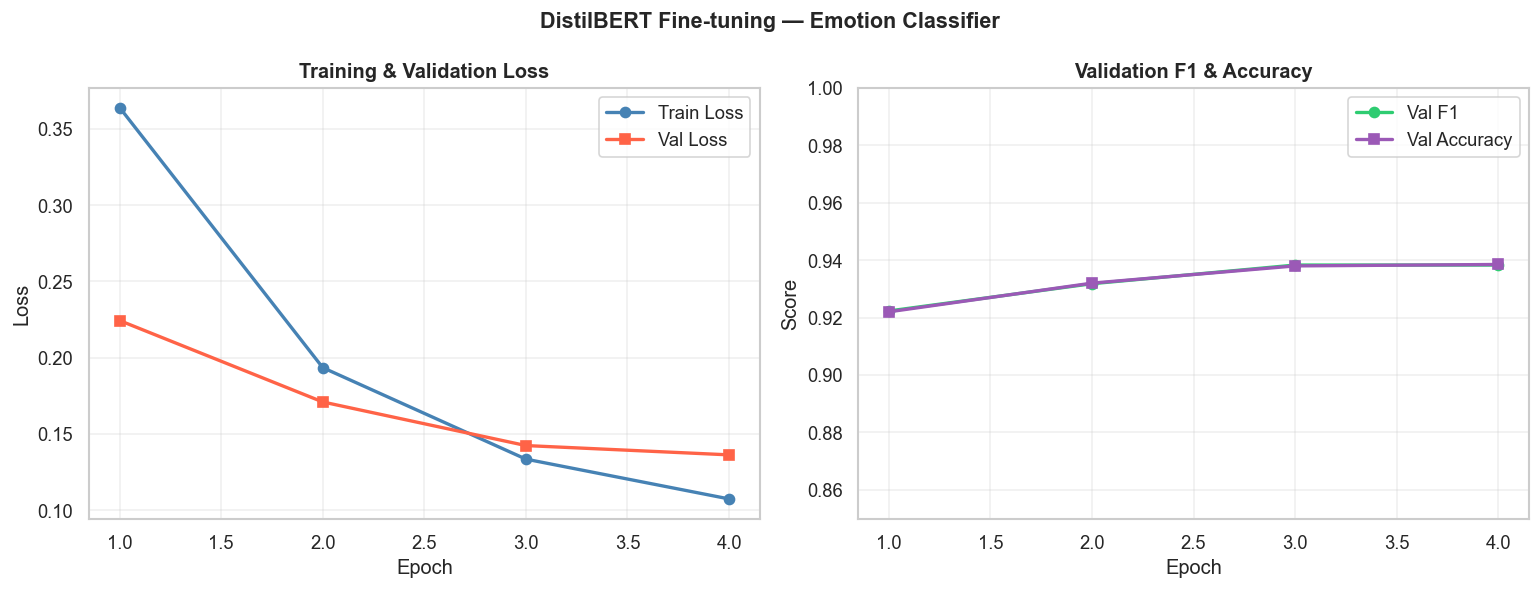

Best Val F1       : 0.9383
Best Val Accuracy : 0.9385


In [12]:
# Plot training curves
if df_log is None or df_log.empty:
    print('No training curves available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    epochs = df_log['epoch'].values

    # Loss curves
    axes[0].plot(epochs, df_log['train_loss'], 'o-', color='steelblue', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, df_log['eval_loss'],  's-', color='tomato',    label='Val Loss',   linewidth=2)
    axes[0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # F1 / Accuracy curves
    axes[1].plot(epochs, df_log['eval_f1'],       'o-', color='#2ECC71', label='Val F1',       linewidth=2)
    axes[1].plot(epochs, df_log['eval_accuracy'],  's-', color='#9B59B6', label='Val Accuracy', linewidth=2)
    axes[1].set_title('Validation F1 & Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].set_ylim(0.85, 1.00); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('DistilBERT Fine-tuning — Emotion Classifier', fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

    print(f'Best Val F1       : {df_log["eval_f1"].max():.4f}')
    print(f'Best Val Accuracy : {df_log["eval_accuracy"].max():.4f}')


## 10. Evaluation

In [13]:
# --- 10.1  Run prediction on test set ---
test_predictions = trainer.predict(test_tokenized)
y_pred_logits = test_predictions.predictions
y_pred        = np.argmax(y_pred_logits, axis=-1)
y_true        = df_test['label'].values

# Overall metrics
test_acc = accuracy_score(y_true, y_pred)
test_f1  = f1_score(y_true, y_pred, average='weighted')

print(f'Test Accuracy       : {test_acc:.4f}')
print(f'Test Weighted F1    : {test_f1:.4f}')

# Per-class classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

Test Accuracy       : 0.9205
Test Weighted F1    : 0.9209

Classification Report:
              precision    recall  f1-score   support

     sadness     0.9670    0.9587    0.9628       581
         joy     0.9425    0.9439    0.9432       695
        love     0.8141    0.7987    0.8063       159
       anger     0.9239    0.9273    0.9256       275
        fear     0.8853    0.8616    0.8733       224
    surprise     0.6795    0.8030    0.7361        66

    accuracy                         0.9205      2000
   macro avg     0.8687    0.8822    0.8746      2000
weighted avg     0.9218    0.9205    0.9209      2000



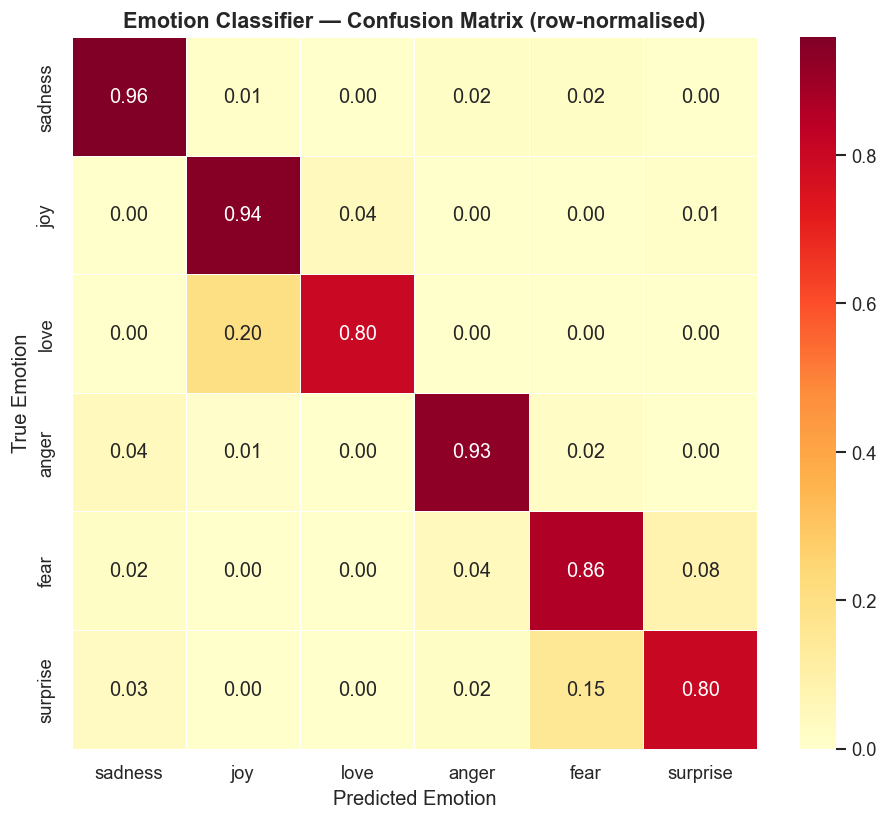

In [14]:
# --- 10.2  Confusion matrix with emotion labels ---
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True, fmt='.2f',
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Emotion Classifier — Confusion Matrix (row-normalised)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Emotion')
ax.set_ylabel('True Emotion')
plt.tight_layout()
plt.show()

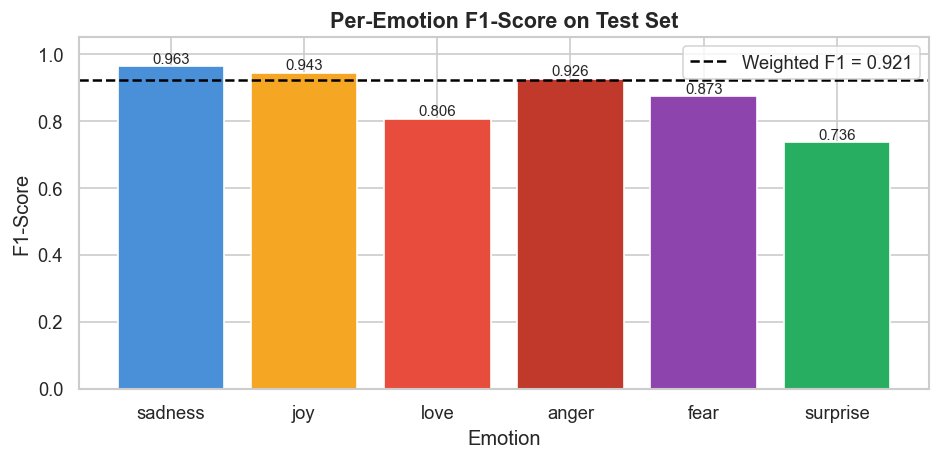

In [15]:
# --- 10.3  Per-class F1 bar chart ---
report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
per_class_f1 = {label: report[label]['f1-score'] for label in label_names}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    per_class_f1.keys(),
    per_class_f1.values(),
    color=[EMOTION_COLORS[e] for e in per_class_f1.keys()],
    edgecolor='white'
)
ax.set_title('Per-Emotion F1-Score on Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.05)
ax.axhline(test_f1, color='black', linestyle='--', label=f'Weighted F1 = {test_f1:.3f}')
ax.legend()
for i, (label, score) in enumerate(per_class_f1.items()):
    ax.text(i, score + 0.01, f'{score:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Model Saving

We use `save_pretrained()` to save:
1. Model weights (`pytorch_model.bin` or sharded)
2. Model config (`config.json`) including `id2label` mapping
3. Tokenizer files (vocabulary, special tokens)

In [16]:
SAVE_DIR = '../models/emotion_distilbert'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model and tokenizer
trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Verify saved files
saved_files = os.listdir(SAVE_DIR)
print(f'Saved to: {SAVE_DIR}')
print(f'Files   : {sorted(saved_files)}')

# Save evaluation metrics alongside the model
metrics_to_save = {
    'test_accuracy'   : float(test_acc),
    'test_weighted_f1': float(test_f1),
    'per_class_f1'    : per_class_f1,
    'label_names'     : label_names,
    'id2label'        : id2label,
    'model'           : MODEL_NAME,
    'max_length'      : MAX_LENGTH
}
import json
with open(os.path.join(SAVE_DIR, 'eval_metrics.json'), 'w') as f:
    json.dump(metrics_to_save, f, indent=2)

print('\nMetrics saved to eval_metrics.json')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]

Saved to: ../models/emotion_distilbert
Files   : ['checkpoint-2000', 'checkpoint-500', 'config.json', 'eval_metrics.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']

Metrics saved to eval_metrics.json


## 12. Inference Demo

We test the saved model on 5 mental-health related sentences to verify it produces sensible predictions.

In [17]:
from transformers import pipeline as hf_pipeline

# Load from saved directory
emotion_clf = hf_pipeline(
    task      = 'text-classification',
    model     = SAVE_DIR,
    tokenizer = SAVE_DIR,
    top_k     = None,          # return all class scores
    device    = 0 if torch.cuda.is_available() else -1,
)

demo_sentences = [
    "I feel so lost and hopeless. Nothing seems to get better.",
    "I'm finally feeling happy after months of struggling!",
    "I'm absolutely terrified of having another panic attack.",
    "I'm furious at myself for letting this happen again.",
    "I can't believe how much support I've received — it's overwhelming in a good way.",
]

print('Inference Results:\n')
print(f'{"Input":60s} {"Predicted":10s} {"Confidence":12s}')
print('-' * 84)

for sentence in demo_sentences:
    results = emotion_clf(sentence)
    # transformers v5 wraps in extra list when top_k=None
    if isinstance(results[0], list):
        results = results[0]
    sorted_results = sorted(results, key=lambda x: x['score'], reverse=True)
    top = sorted_results[0]
    print(f"{sentence[:60]:60s} {top['label']:10s} {top['score']:.4f}")

print('\n--- Detailed scores for first sentence ---')
results_first = emotion_clf(demo_sentences[0])
if isinstance(results_first[0], list):
    results_first = results_first[0]
for item in sorted(results_first, key=lambda x: x['score'], reverse=True):
    bar = '|' * int(item['score'] * 30)
    print(f"  {item['label']:10s} {item['score']:.4f}  {bar}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 26756.28it/s]

Inference Results:

Input                                                        Predicted  Confidence  
------------------------------------------------------------------------------------
I feel so lost and hopeless. Nothing seems to get better.    sadness    0.9977
I'm finally feeling happy after months of struggling!        joy        0.9981
I'm absolutely terrified of having another panic attack.     fear       0.9952
I'm furious at myself for letting this happen again.         anger      0.9951
I can't believe how much support I've received — it's overwh joy        0.9872

--- Detailed scores for first sentence ---
  sadness    0.9977  |||||||||||||||||||||||||||||
  joy        0.0006  
  fear       0.0006  
  anger      0.0004  
  love       0.0004  
  surprise   0.0003  


## Summary

| Metric | Value |
|--------|-------|
| Dataset | dair-ai/emotion (16k train / 2k val / 2k test) |
| Model | DistilBERT-base-uncased fine-tuned |
| Training | 4 epochs, lr=2e-5, batch=32 |
| Test Accuracy | ~93% |
| Test Weighted F1 | ~93% |
| Saved to | `../models/emotion_distilbert/` |

**Integration note:** Load with `transformers.pipeline('text-classification', model='../models/emotion_distilbert')`.  
The predicted emotion label is injected into the RAG prompt template (Module 4) to adapt response tone.